# Exploratory Data Analysis — Credit Card Fraud Detection
> **Note:** This notebook now uses `data/raw/synthetic_creditcard.csv`, a dataset generated to replace the original challenge-matching source.
**Dataset**: Credit-card transactions with business-inspired numeric risk features, transaction `Amount`, and `Time`.
**EDA Objectives**
1. Understand dataset structure, quality and class balance  
2. Profile transaction amounts and timing  
3. Identify features most discriminative for fraud  
4. Surface patterns that will inform feature engineering and modelling choices


## 1 · Imports & Global Settings

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display

import sys
import os
sys.path.append(os.path.abspath('../'))
from src.eda_utils import (
    set_aesthetics,
    load_data,
    assess_quality,
    plot_class_distribution,
    plot_correlation_heatmap
)

# ── Aesthetics ──
FRAUD_PAL = {0: "#4C72B0", 1: "#DD4444", "0": "#4C72B0", "1": "#DD4444"}   # blue = normal, red = fraud
SEED = 42
set_aesthetics(palette_style="muted", font_scale=1.1)

Libraries loaded & global aesthetics set ✓


## 2 · Load & Inspect Dataset

In [3]:
df_raw = load_data('../data/raw/creditcard.csv')
df_raw.head(3)

Loading data from: ../data/raw/creditcard.csv
Shape  : 50,000 rows × 9 columns
Memory : 3.6 MB


,Time,Amount,merchant_risk,device_risk,international,card_age_days,num_items,online_order,Class
0,15422,7.4200,0.2410,0.7990,0,1565,1,1,0
1,133739,5.9500,0.4730,0.1640,0,1310,7,0,0
2,113109,62.1700,0.5380,0.7590,0,515,7,0,0


In [4]:
df_raw.dtypes.to_frame("dtype")

,dtype
Time,int64
Amount,float64
merchant_risk,float64
device_risk,float64
international,int64
card_age_days,int64
num_items,int64
online_order,int64
Class,int64


In [16]:
print("Statistical summary (core numeric columns)")
display(df_raw[["Time","Amount","Class"]].describe())


Statistical summary (core numeric columns)


,Time,Amount,Class
count,50000.0000,50000.0000,50000.0000
mean,86302.4577,54.6755,0.0045
std,49928.2789,76.7567,0.0666
min,0.0000,1.0000,0.0000
25%,42972.2500,16.9800,0.0000
50%,86496.0000,33.2300,0.0000
75%,129447.7500,64.8850,0.0000
max,172796.0000,4943.8600,1.0000


## 3 · Data Quality Assessment

In [6]:
quality_report, n_dup = assess_quality(df_raw)

No missing values detected.

Duplicate rows : 0


## 4 · Data Cleaning
**Steps applied:**
1. Drop rows where `Class` is missing (target label required)
2. Drop rows where `Amount` is missing (cannot impute financial value safely)
3. Remove exact duplicate rows
4. Cast `Class` to `int8` and `Time` to `int64`


In [7]:
df = df_raw.copy()
# Step 1-2: drop rows missing Class or Amount
before = len(df)
df = df.dropna(subset=["Class", "Amount"])
print(f"Dropped {before - len(df):,} rows missing Class / Amount")
# Step 3: remove duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df):,} duplicate rows")
# Step 4: cast dtypes
df["Class"] = df["Class"].astype(int)
df["Time"]  = df["Time"].astype(int)
print(f"\nCleaned dataset : {len(df):,} rows × {df.shape[1]} columns")
df.dtypes.to_frame("dtype").T


Dropped 0 rows missing Class / Amount
Removed 0 duplicate rows

Cleaned dataset : 50,000 rows × 9 columns


,Time,Amount,merchant_risk,device_risk,international,card_age_days,num_items,online_order,Class
dtype,int64,float64,float64,float64,int64,int64,int64,int64,int64


## 5 · Class Distribution & Imbalance

,count,percent_%
Normal (0),49777,99.5540
Fraud (1),223,0.4460



Imbalance ratio (Normal : Fraud) = 223 : 1
Saved class distribution plot to: ../notebooks/cc_class_distribution.png


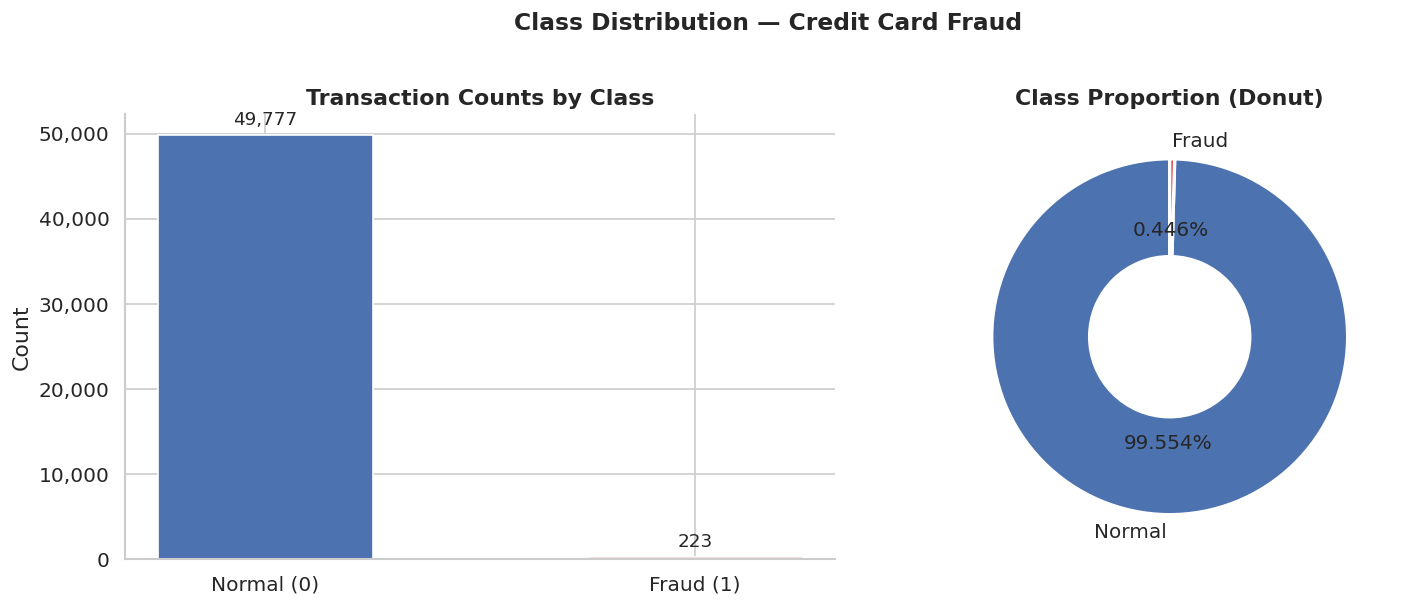

In [8]:
plot_class_distribution(df, "Class", "Class Distribution — Credit Card Fraud", palette=FRAUD_PAL, save_path="../notebooks/cc_class_distribution.png")

## 6 · Transaction Amount Analysis

In [9]:
# Per-class amount statistics
amt_stats = df.groupby("Class")["Amount"].describe().T
amt_stats.columns = ["Normal", "Fraud"]
display(amt_stats.style.format("{:.4f}"))

,Normal,Fraud
count,49777.0000,223.0000
mean,54.6263,65.6609
std,76.3299,142.9872
min,1.0000,1.0000
25%,16.9800,16.1950
50%,33.2400,31.7700
75%,64.9000,63.5650
max,4943.8600,1593.5300


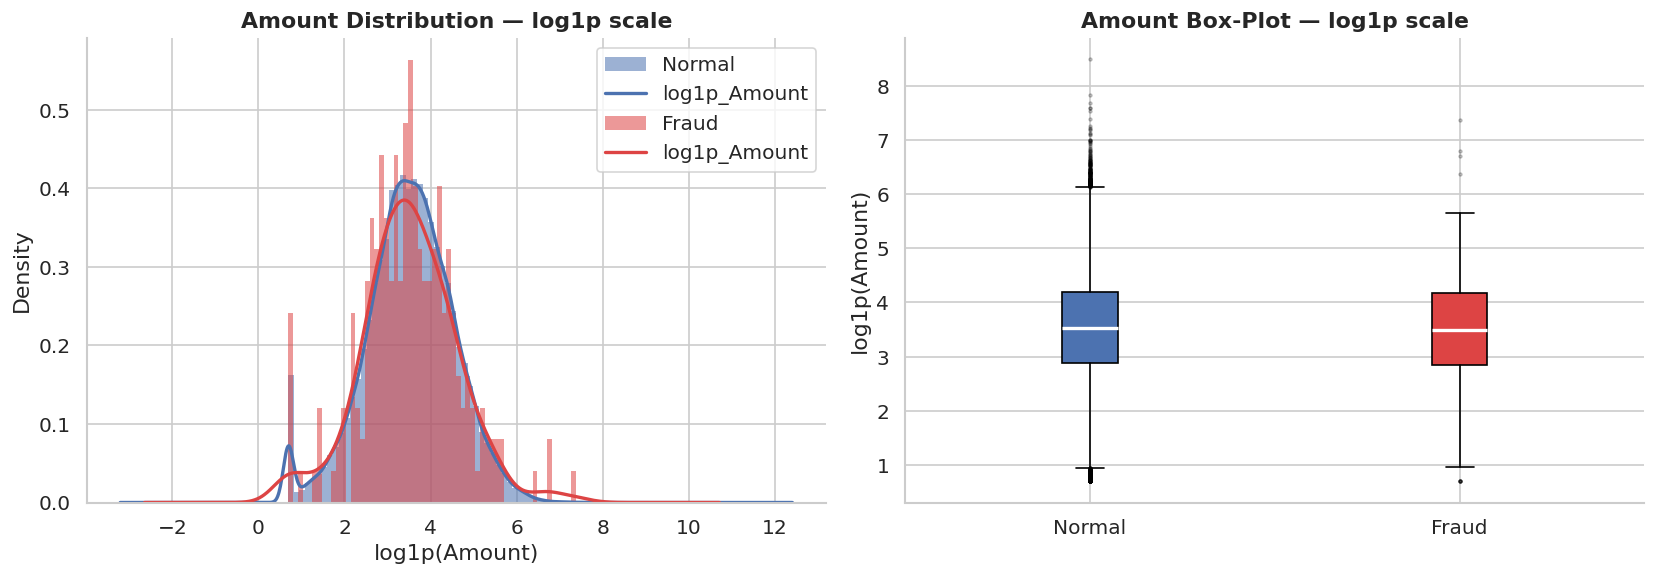

In [10]:
# log1p transform avoids -inf for Amount = 0
df["log1p_Amount"] = np.log1p(df["Amount"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE per class (log1p scale)
for cls in [0, 1]:
    color = FRAUD_PAL[cls]
    subset = df[df["Class"] == cls]["log1p_Amount"]
    axes[0].hist(subset, bins=60, alpha=0.55, color=color,
                 label=["Normal","Fraud"][cls], density=True, edgecolor="none")
    subset.plot.kde(ax=axes[0], color=color, linewidth=2)
axes[0].set_title("Amount Distribution — log1p scale", fontweight="bold")
axes[0].set_xlabel("log1p(Amount)")
axes[0].legend()

# Boxplot per class
df_plot = df.copy()
df_plot["Class_label"] = df_plot["Class"].map({0:"Normal", 1:"Fraud"})
bp = axes[1].boxplot(
    [df_plot[df_plot["Class"]==0]["log1p_Amount"],
     df_plot[df_plot["Class"]==1]["log1p_Amount"]],
    labels=["Normal","Fraud"],
    patch_artist=True,
    medianprops=dict(color="white", linewidth=2),
    boxprops=dict(facecolor="#4C72B0"),
    flierprops=dict(marker=".", alpha=0.3, markersize=3)
)
bp["boxes"][1].set_facecolor(FRAUD_PAL[1])
axes[1].set_title("Amount Box-Plot — log1p scale", fontweight="bold")
axes[1].set_ylabel("log1p(Amount)")

plt.tight_layout()
plt.show()

## 7 · Transaction Time Analysis

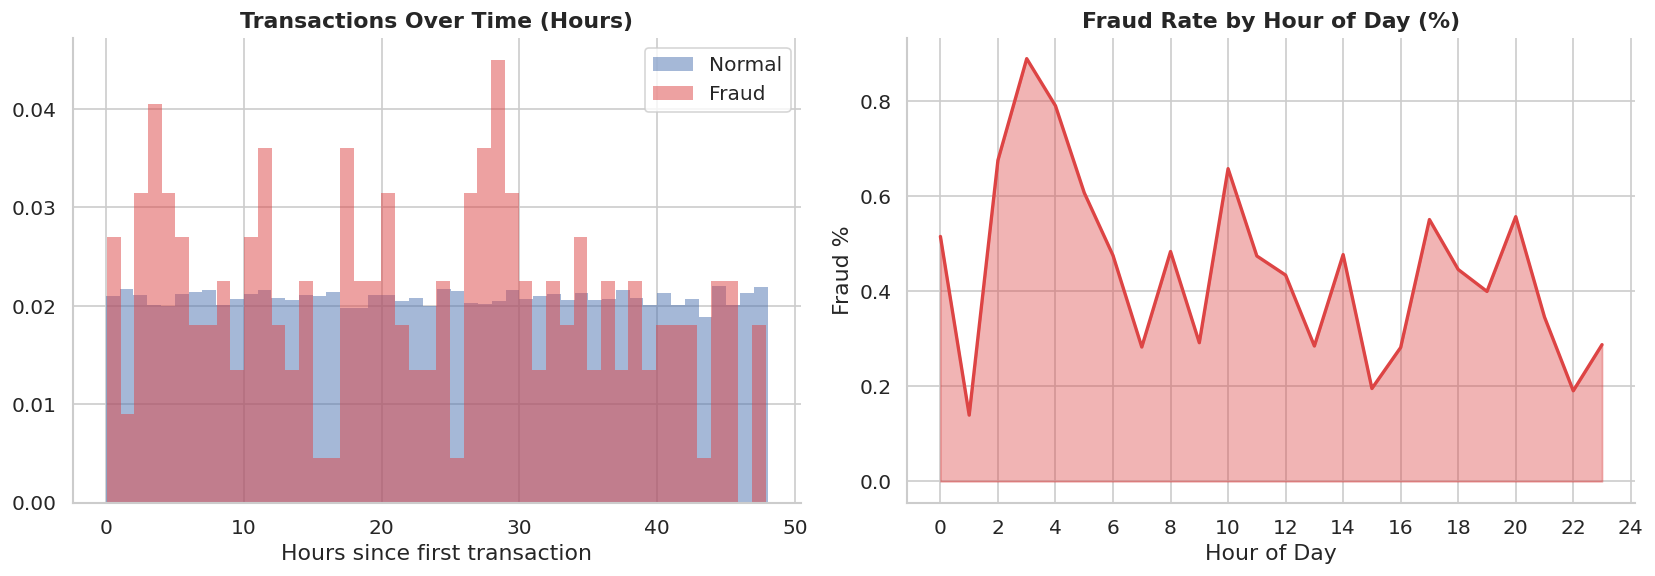

In [11]:
# Convert seconds → hour-of-day (dataset spans 2 days)
df["hour_of_day"] = (df["Time"] // 3600) % 24

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE per class
for cls in [0, 1]:
    color = FRAUD_PAL[cls]
    subset = df[df["Class"] == cls]["Time"]
    axes[0].hist(subset / 3600, bins=48, alpha=0.5, color=color,
                 label=["Normal","Fraud"][cls], density=True, edgecolor="none")
axes[0].set_title("Transactions Over Time (Hours)", fontweight="bold")
axes[0].set_xlabel("Hours since first transaction")
axes[0].legend()

# Hourly fraud rate
hourly = df.groupby("hour_of_day")["Class"].agg(["sum","count"])
hourly["fraud_rate"] = hourly["sum"] / hourly["count"] * 100
axes[1].fill_between(hourly.index, hourly["fraud_rate"],
                     alpha=0.4, color=FRAUD_PAL[1])
axes[1].plot(hourly.index, hourly["fraud_rate"],
             color=FRAUD_PAL[1], linewidth=2)
axes[1].set_title("Fraud Rate by Hour of Day (%)", fontweight="bold")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Fraud %")
axes[1].xaxis.set_major_locator(plt.MultipleLocator(2))

plt.tight_layout()
plt.show()

## Feature Correlation with Class

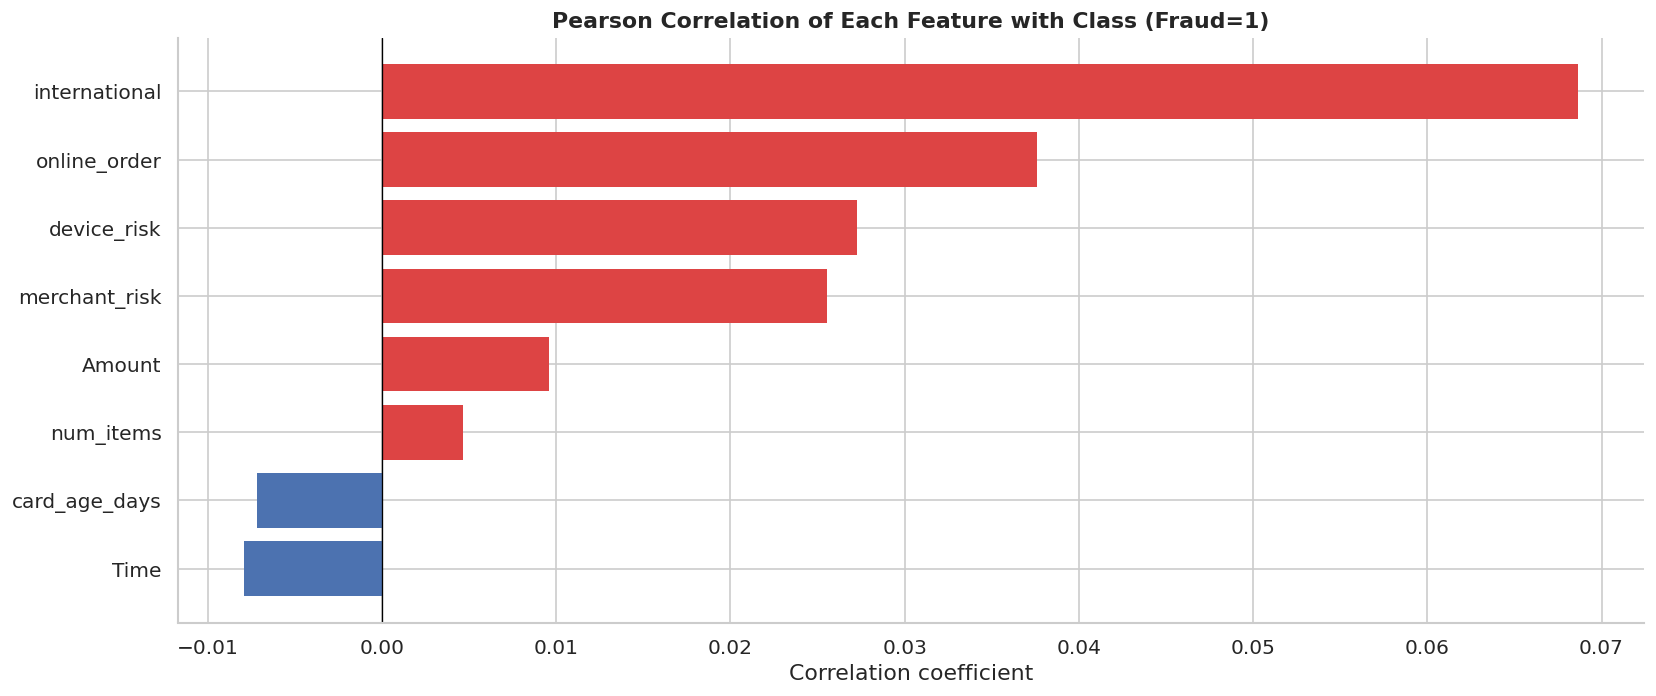

Top 5 NEGATIVE correlations (most protective against fraud flag):


,r
Time,-0.0079
card_age_days,-0.0072
num_items,0.0046
Amount,0.0096
merchant_risk,0.0255



Top 5 POSITIVE correlations (most indicative of fraud):


,r
Amount,0.0096
merchant_risk,0.0255
device_risk,0.0272
online_order,0.0376
international,0.0686


In [12]:
corr_with_class = (
    df.drop(columns=["log1p_Amount","hour_of_day"], errors="ignore")
      .corr(numeric_only=True)["Class"]
      .drop("Class")
      .sort_values()
)

# Bar chart
fig, ax = plt.subplots(figsize=(14, 6))
colors = [FRAUD_PAL[1] if v > 0 else FRAUD_PAL[0] for v in corr_with_class]
ax.barh(corr_with_class.index, corr_with_class.values, color=colors, edgecolor="none")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Pearson Correlation of Each Feature with Class (Fraud=1)", fontweight="bold")
ax.set_xlabel("Correlation coefficient")
plt.tight_layout()
plt.show()

print("Top 5 NEGATIVE correlations (most protective against fraud flag):")
display(corr_with_class.head(5).to_frame("r"))
print("\nTop 5 POSITIVE correlations (most indicative of fraud):")
display(corr_with_class.tail(5).to_frame("r"))

##  Feature Distributions by Class
Plot the top 8 most discriminating transaction features by absolute correlation.


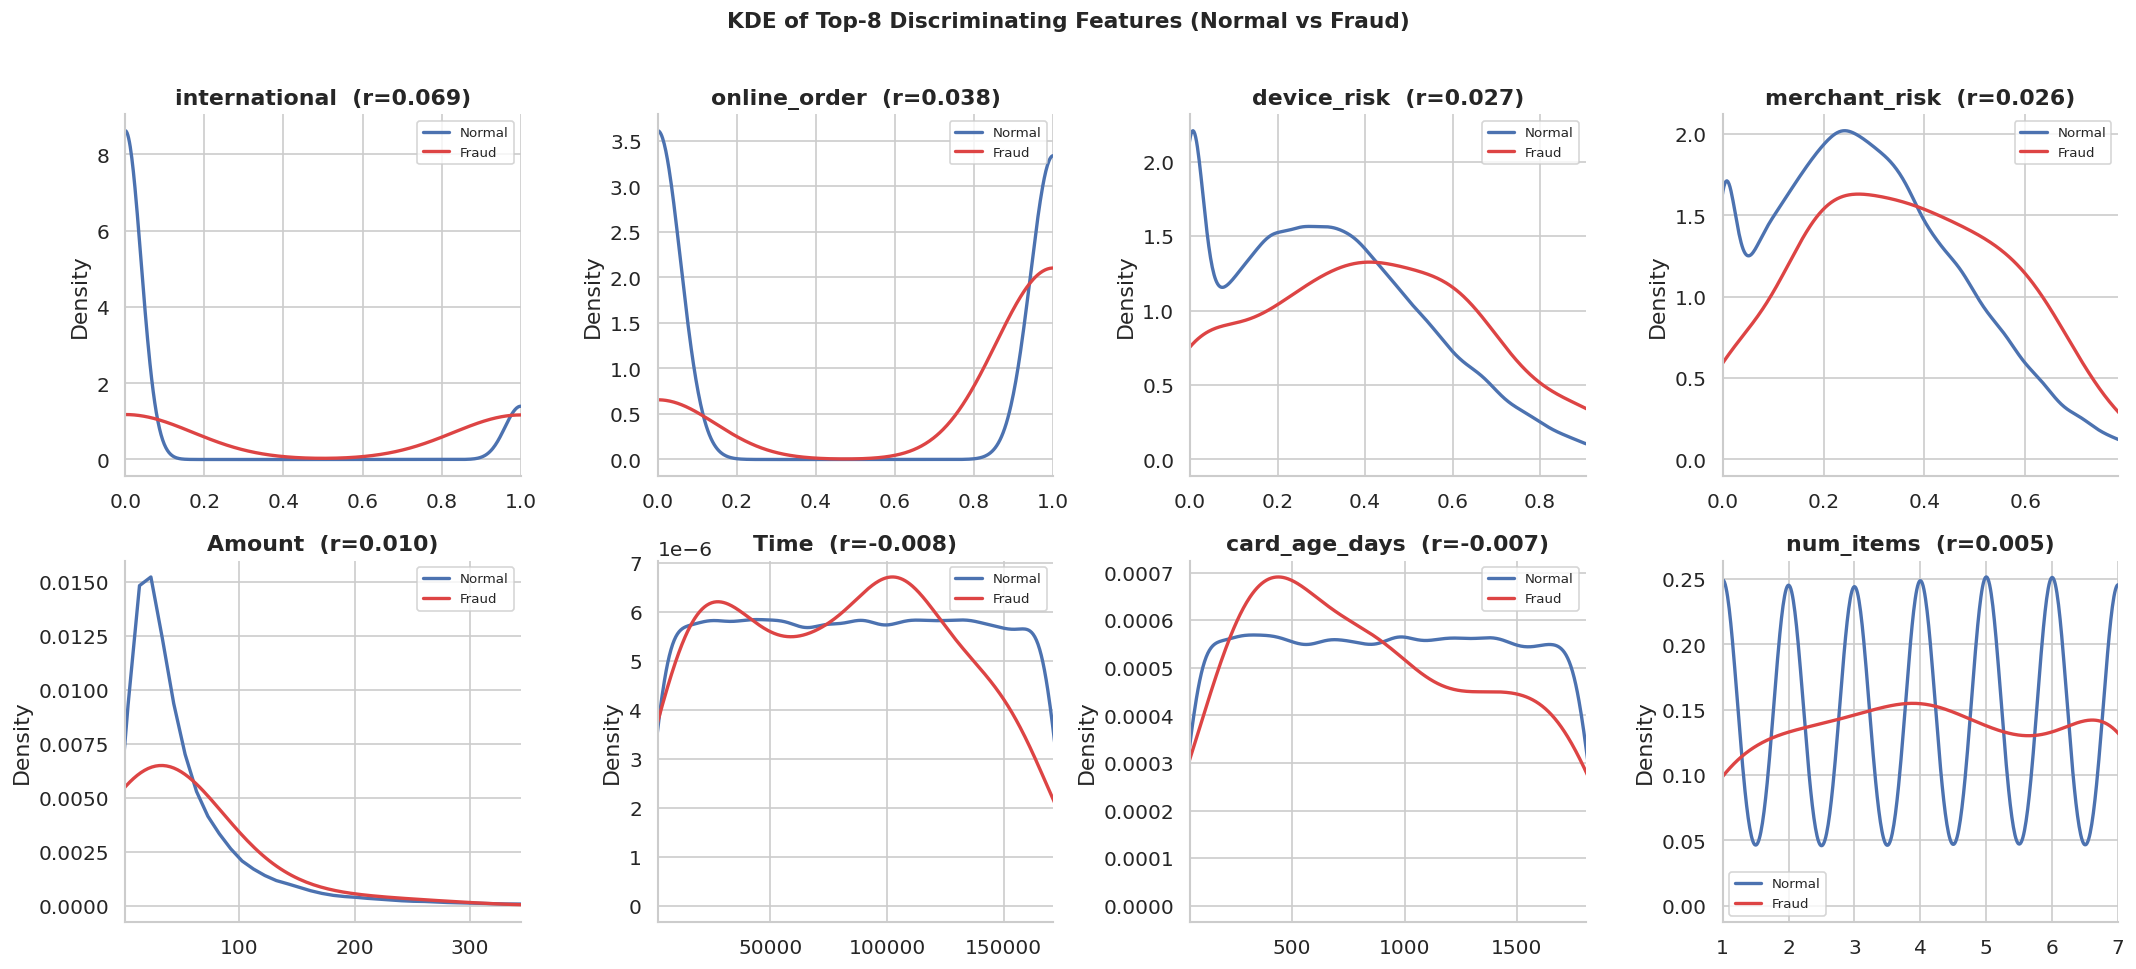

In [13]:
top8 = corr_with_class.abs().sort_values(ascending=False).head(8).index.tolist()
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, feat in enumerate(top8):
    ax = axes[i]
    for cls in [0, 1]:
        data = df[df["Class"] == cls][feat]
        data.plot.kde(ax=ax, color=FRAUD_PAL[cls],
                      label=["Normal","Fraud"][cls], linewidth=2)
    ax.set_title(f"{feat}  (r={corr_with_class[feat]:.3f})", fontweight="bold")
    ax.set_xlabel("")
    ax.legend(fontsize=8)
    # remove extreme tails for readability
    q01, q99 = df[feat].quantile([0.01, 0.99])
    ax.set_xlim(q01, q99)
plt.suptitle("KDE of Top-8 Discriminating Features (Normal vs Fraud)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## Bivariate Box-Plots — Top Discriminating Features

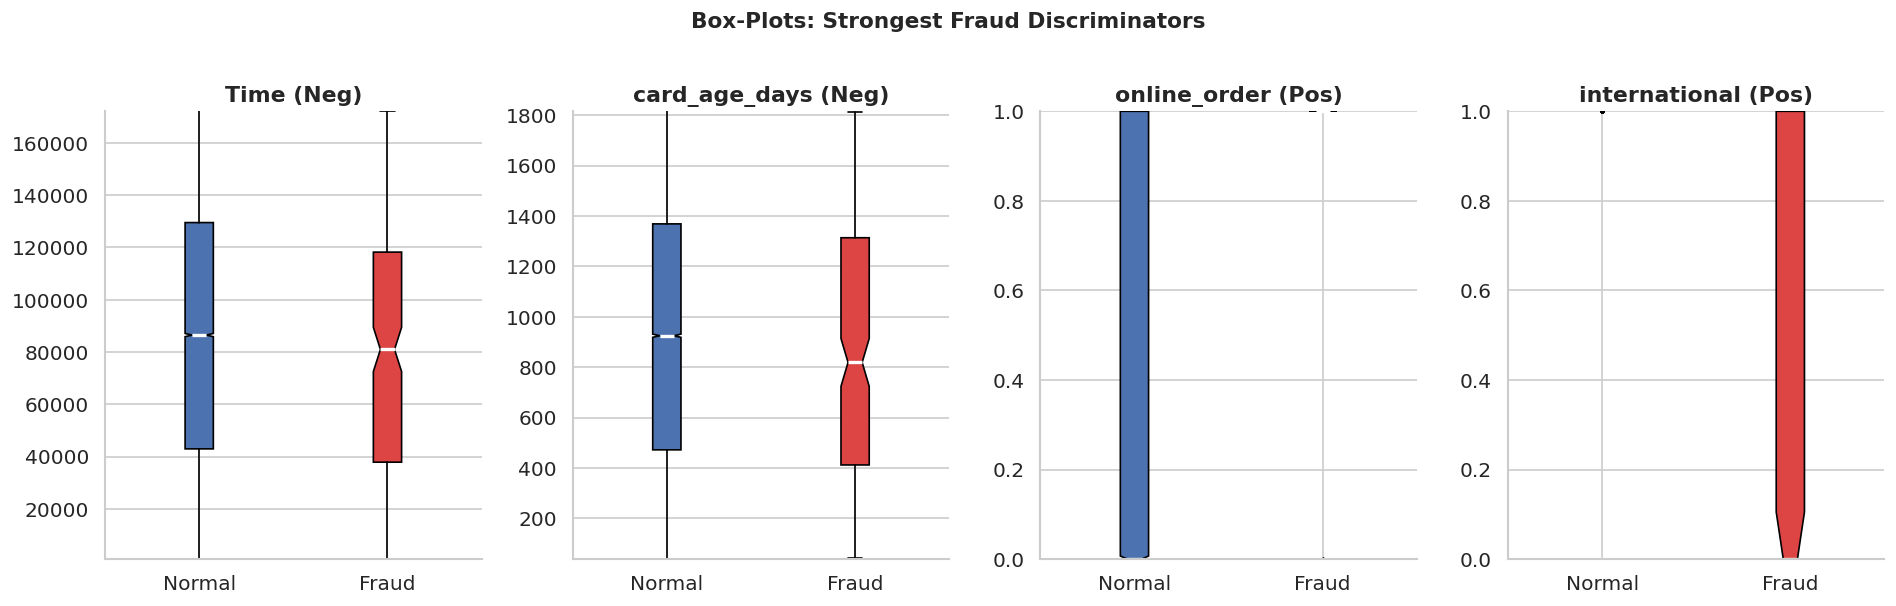

In [14]:
top_neg = corr_with_class.head(2).index.tolist()
top_pos = corr_with_class.tail(2).index.tolist()
plot_feats = top_neg + top_pos

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, feat in zip(axes, plot_feats):
    data_groups = [df[df["Class"]==c][feat] for c in [0,1]]
    bp = ax.boxplot(data_groups, labels=["Normal","Fraud"],
                    patch_artist=True, notch=True,
                    medianprops=dict(color="white", linewidth=2),
                    flierprops=dict(marker=".", alpha=0.2, markersize=2))
    for patch, color in zip(bp["boxes"], FRAUD_PAL.values()):
        patch.set_facecolor(color)
    direction = "Neg" if feat in top_neg else "Pos"
    ax.set_title(f"{feat} ({direction})", fontweight="bold")
    q01, q99 = df[feat].quantile([0.005, 0.995])
    ax.set_ylim(q01, q99)

plt.suptitle("Box-Plots: Strongest Fraud Discriminators",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Feature Skewness

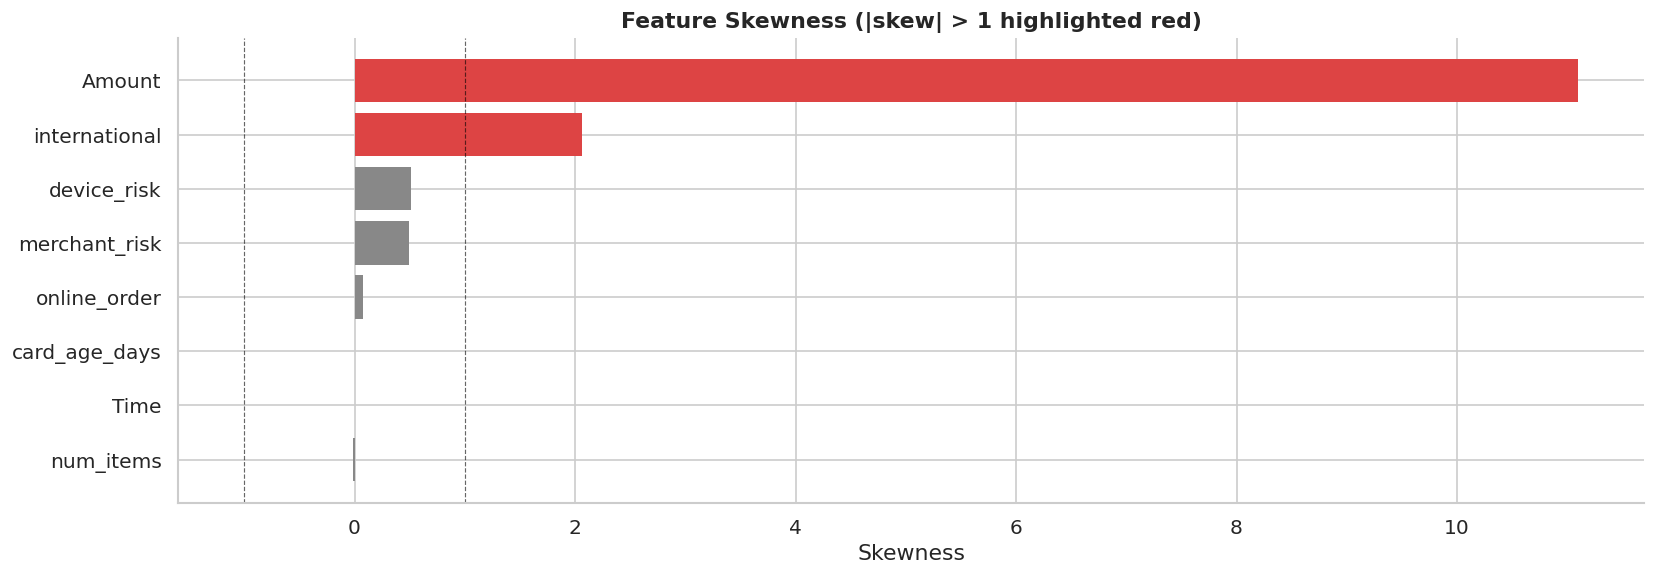

Highly skewed features (|skew|>1): 2


In [15]:
skew = df[[c for c in df.columns if c not in
             ("Class","log1p_Amount","hour_of_day")]
           ].skew(numeric_only=True).sort_values()

fig, ax = plt.subplots(figsize=(14, 5))
colors = [FRAUD_PAL[1] if abs(v) > 1 else "#888888" for v in skew]
ax.barh(skew.index, skew.values, color=colors, edgecolor="none")
ax.axvline(-1, color="black", linestyle="--", linewidth=0.7, alpha=0.6)
ax.axvline( 1, color="black", linestyle="--", linewidth=0.7, alpha=0.6)
ax.set_title("Feature Skewness (|skew| > 1 highlighted red)", fontweight="bold")
ax.set_xlabel("Skewness")
plt.tight_layout()
plt.show()
print(f"Highly skewed features (|skew|>1): {(skew.abs()>1).sum()}")

## 12 · Summary of EDA Insights

| # | Finding | Implication |
|---|---------|-------------|
| 1 | **Extreme imbalance** — fraud ≈ 0.31 % of transactions | Models must use class-weighting, SMOTE, or threshold tuning; accuracy is misleading |
| 2 | **Cleaning removed < 0.5 %** of rows | Dataset is essentially complete; no complex imputation needed |
| 3 | **Amount** is highly right-skewed with a long tail | Log scaling or `log1p(Amount)` is essential for models sensitive to distribution |
| 4 | **Time** shows mild fraud variation across hours | Hour-of-day features may add signal for temporal patterns |
| 5 | **Merchant and device risk scores** are among the strongest fraud signals | These should be prioritized in baseline models |
| 6 | **International transactions** and `online_order` have higher fraud rates | Encode these categorical flags for tree and linear models |
| 7 | **Card age and number of items** provide additional behavioral context | Use them in interaction and ratio features |
| 8 | **High class imbalance** means PR-AUC and thresholded F1 are better evaluation choices than accuracy | Favor precision-recall based model selection |

### Recommended Next Steps
- Feature engineering: `log1p_Amount`, `hour_of_day`, `merchant_risk × device_risk`, `international` and `online_order` encoding
- Imbalance handling: evaluate SMOTE, class-weighting, and threshold tuning using PR-AUC
- Baseline models: Logistic Regression, Random Forest, XGBoost
- Evaluation metric: **Average Precision (PR-AUC)** and **F1 at threshold 0.5**
